# 커스텀 모델


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 22.9 MB/s eta 0:00:00


In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from PIL import Image, ImageDraw
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

import random
from torchmetrics.detection.mean_ap import MeanAveragePrecision

## Custom Model 설계 및 개선

- Backbone + Head 구조로 직접 객체 탐지 모델 설계
- 10×10 Grid 기반으로 이미지 영역을 분할
- 각 Grid Cell마다 2개의 Anchor Box를 사용하여 다양한 객체 크기에 대응
- BatchNorm을 추가하여 학습 안정성 향상
- 위치 오차, 신뢰도 오차, 분류 오차를 합산한 Loss Function 설계
- NMS를 직접 구현하여 중복 bounding box 제거

Train 로직

Custom Model 데이터셋 인코딩 및 Target Tensor 설계

- 입력 이미지를 10×10 Grid로 분할
- 각 Grid Cell마다 2개의 Anchor Box 할당
  - 정사각형 형태: helmet 등 작은 객체 고려
  - 세로 직사각형 형태: person, vest 등 세로로 긴 객체 고려

Target Tensor 구성
- 각 Anchor Box마다 총 10개 값 예측
  - x, y: 객체 중심 좌표
  - w, h: bounding box 크기
  - confidence: 객체 존재 여부
  - class probability: 5개 클래스 one-hot encoding

Anchor 할당 방식
- Ground Truth Box와 2개 Anchor Box의 IoU 계산
- 가장 IoU가 높은 Anchor를 정답 Anchor로 선택
- 객체가 없는 Grid Cell은 background로 처리하고 confidence를 0으로 설정

In [ ]:
# 데이터셋 클래스 (정답지 인코딩)
class CustomPPEDataset(Dataset):
    def __init__(self, img_dir, label_dir, grid_size=10, num_classes=5, transform=None):
        self.img_dir = img_dir
        self.label_dir = label_dir
        self.transform = transform
        self.S = grid_size
        self.C = num_classes

        # 2개의 기본 앵커 모양 정의 (가로, 세로 비율)
        # 앵커 0: (0.1, 0.1) -> 안전모처럼 작은 정사각형
        # 앵커 1: (0.3, 0.6) -> 사람, 조끼처럼 길쭉한 직사각형
        self.anchors = [[0.1, 0.1], [0.3, 0.6]]
        self.num_anchors = len(self.anchors)

        # jpg 파일 목록만 추려냄
        self.image_files = [f for f in os.listdir(img_dir) if f.endswith('.jpg')]

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        # 이미지 로드
        img_name = self.image_files[idx]
        img_path = os.path.join(self.img_dir, img_name)
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        # 1정답지 텐서 크기 확장: (10, 10, 2개의 앵커, 10개 데이터)
        target_tensor = torch.zeros((self.S, self.S, self.num_anchors, 5 + self.C))

        # 텍스트 라벨 로드 및 10x10 그리드 맵핑
        label_name = img_name.replace(".jpg", ".txt")
        label_path = os.path.join(self.label_dir, label_name)

        if os.path.exists(label_path):
            with open(label_path, "r") as f:
                for line in f.readlines():
                    class_label, x, y, w, h = map(float, line.strip().split())
                    class_label = int(class_label)

                    # 몇 번째 칸인지 계산 (i: 세로축, j: 가로축)
                    i, j = int(self.S * y), int(self.S * x)

                    # 칸 내부의 상대 좌표 계산
                    x_cell = self.S * x - j
                    y_cell = self.S * y - i

                    # 현재 정답(w, h)과 가장 모양이 비슷한 앵커 찾기 (IoU 경쟁)(박스가 얼마나 겹치는지)
                    best_iou = 0
                    best_anchor = 0
                    for a_idx, anchor in enumerate(self.anchors):
                        inter_w = min(w, anchor[0])
                        inter_h = min(h, anchor[1])
                        inter_area = inter_w * inter_h
                        union_area = (w * h) + (anchor[0] * anchor[1]) - inter_area
                        iou = inter_area / union_area if union_area > 0 else 0

                        if iou > best_iou:
                            best_iou = iou
                            best_anchor = a_idx

                    # 1등으로 선정된 앵커 자리에만 정답 입력 (승자 독식)
                    if target_tensor[i, j, best_anchor, 4] == 0:
                        target_tensor[i, j, best_anchor, 0:5] = torch.tensor([x_cell, y_cell, w, h, 1.0])
                        target_tensor[i, j, best_anchor, 5 + class_label] = 1.0

        return image, target_tensor


Custom Model 아키텍처 설계

본 모델은 640×640×3 크기의 이미지를 입력받아 객체 탐지를 수행하도록 직접 설계하였다. 전체 구조는 이미지 특징을 추출하는 Backbone과 객체의 위치 및 클래스를 예측하는 Head로 구성하였다.

Backbone 구조

- 총 6개의 Convolution Block으로 구성
- 각 Block은 Conv → BatchNorm → ReLU → MaxPool 순서로 설계
- 채널 수는 3 → 16 → 32 → 64 → 128로 확장
- 최종적으로 10×10×128 크기의 Feature Map 출력

BatchNorm 추가 이유

- 학습 과정에서 값의 분포를 안정화
- 가중치 초기화에 대한 민감도 감소
- 학습 속도와 안정성 향상

Head 구조

- 1×1 Convolution을 사용하여 128개 채널을 20개 채널로 압축
- 최종 출력 크기: 10×10×20
- 각 Grid Cell마다 2개의 Anchor Box 예측
- Anchor 1개당 10개 값 예측

Anchor 1개당 예측값

[x, y, w, h, confidence, class1, class2, class3, class4, class5]

출력값 처리 방식

- x, y: 중심 좌표이므로 Sigmoid 적용
- w, h: 박스 크기이므로 Exponential 적용
- confidence: 객체 존재 확률이므로 Sigmoid 적용
- class logits: CrossEntropyLoss에서 처리되므로 원본값 유지

이를 통해 각 Grid Cell에서 객체의 위치, 크기, 존재 여부, 클래스를 동시에 예측할 수 있도록 Custom Detection Model을 구성하였다.

In [ ]:
# 모델 설계 (Backbone + Head)
class Custom(nn.Module):
    def __init__(self):
        super(Custom, self).__init__()

        # 블럭 1: 640 -> 320, 3 -> 16
        self.block1 = self._make_block(in_c=3, out_c=16, num_convs=1)
        # 블럭 2: 320 -> 160, 16 -> 32
        self.block2 = self._make_block(in_c=16, out_c=32, num_convs=1)
        # 블럭 3: 160 -> 80, 32 -> 64 (Conv 2개)
        self.block3 = self._make_block(in_c=32, out_c=64, num_convs=2)
        # 블럭 4: 80 -> 40, 64 -> 64 (Conv 2개)
        self.block4 = self._make_block(in_c=64, out_c=64, num_convs=2)
        # 블럭 5: 40 -> 20, 64 -> 128 (Conv 2개)
        self.block5 = self._make_block(in_c=64, out_c=128, num_convs=2)
        # 블럭 6: 20 -> 10, 128 -> 128 (Conv 2개)
        self.block6 = self._make_block(in_c=128, out_c=128, num_convs=2)

        # 10채널(박스 1개) -> 20채널(박스 2개)로 두 배 늘림
        self.head = nn.Conv2d(in_channels=128, out_channels=20, kernel_size=1)

        # 앵커 크기 정보를 모델에 등록 (GPU 연산을 위해 버퍼로 등록)
        self.register_buffer('anchors', torch.tensor([[0.1, 0.1], [0.3, 0.6]]))

    def _make_block(self, in_c, out_c, num_convs):
        layers = []
        layers.append(nn.Conv2d(in_c, out_c, kernel_size=3, padding=1))
        layers.append(nn.BatchNorm2d(out_c)) #배치 정규화
        layers.append(nn.ReLU())

        if num_convs == 2:
            layers.append(nn.Conv2d(out_c, out_c, kernel_size=3, padding=1))
            layers.append(nn.BatchNorm2d(out_c)) #배치 정규화
            layers.append(nn.ReLU())

        layers.append(nn.MaxPool2d(kernel_size=2, stride=2))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.block5(x)
        x = self.block6(x)

        # (Batch, 128, 10, 10) -> (Batch, 10, 10, 10) (기존 V1)
        out = self.head(x)

        # 후처리를 쉽게 하기위해 20채널을 뒤로 보냄 -> (Batch, 10, 10, 20채널)
        out = out.permute(0, 2, 3, 1)

        # 20개의 채널을 (2개의 앵커 x 10개의 데이터) 형태로 반으로 나눠 분리
        out = out.view(-1, 10, 10, 2, 10)

        # --- 최종 출력층에 활성화 함수 적용 ---
        # 0~1: x, y 좌표, 0에서 1 사이의 값이 나와야 하므로 시그모이드(Sigmoid) 처리
        xy = torch.sigmoid(out[..., 0:2])

        # 2~3: w, h 크기 (음수 방지 및 스케일링을 위해 Exponential)
        # 예측한 크기 오프셋(exp)에 기본 앵커 크기를 곱해줌
        wh = torch.exp(out[..., 2:4]) * self.anchors.view(1, 1, 1, 2, 2)

        # 4: 객체 신뢰도 (Sigmoid)
        conf = torch.sigmoid(out[..., 4:5])

        # 5~9: 5개 클래스 로짓 (CrossEntropyLoss를 위해 날것의 로짓 유지 나중에 알아서 (Softmax)처리해줌)
        cls_logits = out[..., 5:]

        return torch.cat([xy, wh, conf, cls_logits], dim=-1)



## Loss Function

Custom Model은 세 가지 오차를 합산하여 학습하였다.

- Localization Loss: 예측 box와 실제 box의 위치 차이 계산
- Confidence Loss: 객체 존재 여부 예측 오차 계산
- Classification Loss: 객체 클래스 분류 오차 계산

이를 통해 모델이 객체의 위치, 존재 여부, 클래스를 동시에 학습하도록 구성하였다.

In [ ]:
# 채점 기준 설계 (Loss Function)
class Loss(nn.Module):
    def __init__(self, lambda_noobj=0.5):
        super(Loss, self).__init__()
        # 객체가 없는 배경 칸의 신뢰도 오차 가중치를 낮춤 (사진은 대부분 배경이므로)
        self.lambda_noobj = lambda_noobj

    def forward(self, preds, targets):
        """
        preds: (Batch, 10, 10, 2, 10)
        targets: (Batch, 10, 10, 2, 10)
        """
        # 정답지의 신뢰도(인덱스 4)를 기준으로 객체가 있는 칸과 없는 칸 구분
        # 차원이 늘어나도 파이토치 마스크가 알아서 앵커별로 패자를 가려냄
        obj_mask = targets[..., 4] > 0
        noobj_mask = targets[..., 4] == 0

        # [1] 위치 오차 (MSE) - 객체가 존재하는 칸에서만 계산
        pred_box = preds[..., 0:4][obj_mask]
        target_box = targets[..., 0:4][obj_mask]
        loss_box = F.mse_loss(pred_box, target_box, reduction='sum')

        # [2] 신뢰도 오차 (MSE)
        # 객체가 있는 칸: 신뢰도가 1에 가까워지도록
        pred_conf_obj = preds[..., 4][obj_mask]
        target_conf_obj = targets[..., 4][obj_mask]
        loss_conf_obj = F.mse_loss(pred_conf_obj, target_conf_obj, reduction='sum')

        # 객체가 없는 칸: 신뢰도가 0에 가까워지도록 (가중치 lambda_noobj 적용)
        pred_conf_noobj = preds[..., 4][noobj_mask]
        target_conf_noobj = targets[..., 4][noobj_mask]
        loss_conf_noobj = F.mse_loss(pred_conf_noobj, target_conf_noobj, reduction='sum') * self.lambda_noobj

        loss_conf = loss_conf_obj + loss_conf_noobj

        # [3] 분류 오차 (Cross Entropy) - 객체가 존재하는 칸에서만 계산
        pred_cls = preds[..., 5:][obj_mask]
        target_cls = targets[..., 5:][obj_mask]

        loss_cls = 0.0
        if pred_cls.numel() > 0: # 객체가 하나라도 있을 때만 계산
            # 정답지 원핫 텐서를 다시 클래스 인덱스(0~4)로 변환
            target_cls_idx = target_cls.argmax(dim=-1)
            loss_cls = F.cross_entropy(pred_cls, target_cls_idx, reduction='sum')

        # 전체 Loss 합산 (배치 크기로 나누어 평균화)
        total_loss = (loss_box + loss_conf + loss_cls) / preds.size(0)

        return total_loss

## Custom Model 학습 과정

### 1. 데이터 로드

* `CustomPPEDataset`을 활용하여 학습용 데이터와 검증용 데이터를 분리하였다.
* 학습 데이터는 매 Epoch마다 Shuffle하여 데이터 순서에 따른 편향을 줄였다.
* 검증 데이터는 일관된 성능 평가를 위해 순서를 고정하였다.

### 2. 모델 학습

* Optimizer: Adam
* Learning Rate: 0.001
* 최대 Epoch: 50

입력 이미지로부터 예측값을 생성한 뒤, 정답 Target과 비교하여 Loss를 계산하였다. 이후 Backpropagation을 통해 Loss가 감소하도록 모델의 가중치를 업데이트하였다.

### 3. 모델 검증 및 저장

매 Epoch 종료 후 모델을 평가 모드로 전환하고, 기울기 계산 없이 Validation Loss를 측정하였다.

Validation Loss가 이전 최저값보다 감소한 경우 해당 모델의 가중치를 `best_custom_detector.pth` 파일로 저장하였다.

### 4. Early Stopping

Validation Loss가 연속 5 Epoch 동안 개선되지 않을 경우 학습을 종료하도록 설정하였다.

이를 통해 불필요한 반복 학습을 줄이고, Validation Loss가 가장 낮은 시점의 모델 가중치를 최종 모델로 선택하였다.


In [ ]:
# 학습 단계 파이프라인
def train():
    BASE_DIR = "/content/drive/MyDrive/기계학습_2조/data/processed/Detection"
    # 폴더 경로 설정
    TRAIN_IMG_DIR = f"{BASE_DIR}/images/train"
    TRAIN_LABEL_DIR = f"{BASE_DIR}/yolo_labels/train"
    VAL_IMG_DIR = f"{BASE_DIR}/images/val"
    VAL_LABEL_DIR = f"{BASE_DIR}/yolo_labels/val"

    # 테스트를 위해 폴더가 없으면 임시로 생성해주는 방어 코드
    os.makedirs(TRAIN_IMG_DIR, exist_ok=True)
    os.makedirs(TRAIN_LABEL_DIR, exist_ok=True)
    os.makedirs(VAL_IMG_DIR, exist_ok=True)
    os.makedirs(VAL_LABEL_DIR, exist_ok=True)

    # 디바이스 설정 (GPU 지원 시 GPU 사용)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"사용 중인 장치: {device}")

    # 이미지 크기를 640x640으로 맞추고 텐서로 변환
    transform = transforms.Compose([
        transforms.Resize((640, 640)),
        transforms.ToTensor()
    ])

    # 데이터셋 및 데이터로더 생성 (Train)
    train_dataset = CustomPPEDataset(img_dir=TRAIN_IMG_DIR, label_dir=TRAIN_LABEL_DIR, transform=transform)
    train_dataloader = DataLoader(train_dataset, batch_size=4, shuffle=True)

    # 데이터셋 및 데이터로더 생성 (Validation)
    # 검증할 때는 데이터를 섞을(shuffle) 필요가 없음.
    val_dataset = CustomPPEDataset(img_dir=VAL_IMG_DIR, label_dir=VAL_LABEL_DIR, transform=transform)
    val_dataloader = DataLoader(val_dataset, batch_size=4, shuffle=False)

    if len(train_dataset) == 0 or len(val_dataset) == 0:
        print("경고: Train 또는 Val 폴더에 이미지가 없습니다. 경로를 확인해주세요.")
        return

    # 모델 및 Loss 생성
    model = Custom().to(device)
    criterion = Loss()

    # 옵티마이저 설정 (Adam 사용)
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    epochs = 50 # 에포크 횟수
    patience = 5 # 최대 몇번 val loss 증가하지 않으면 멈출지 (early stopping)
    trigger_times = 0 # 참은 횟수 카운터
    best_val_loss = float('inf') # 최고 기록을 기억할 변수 (초기값은 무한대)
    save_path = "/content/drive/MyDrive/기계학습_2조/data/processed/Detection/best_custom_detector.pth"

    for epoch in range(epochs):
        train_epoch_loss = 0
        model.train()
        for images, targets in train_dataloader:
            images, targets = images.to(device), targets.to(device)
            optimizer.zero_grad()

            # 1. 데이터 입력 및 순전파
            predictions = model(images)

            # 2. 시험 및 채점 (Loss Function)
            loss = criterion(predictions, targets)

            # 3. 오차 역전파 및 최적화
            loss.backward()
            optimizer.step()
            train_epoch_loss += loss.item()

        avg_train_loss = train_epoch_loss / len(train_dataloader)

        #모델 검증 단계 (Validation)
        model.eval() # 모델을 평가 모드로 설정 (가중치 업데이트 금지, 고정)
        val_epoch_loss = 0

        # no_grad(): 검증 단계에서는 기울기(gradient) 계산을 하지 않아 메모리를 절약하고 속도를 높임
        with torch.no_grad():
            for images, targets in val_dataloader:
                images, targets = images.to(device), targets.to(device)

                predictions = model(images)
                loss = criterion(predictions, targets)
                val_epoch_loss += loss.item()

        avg_val_loss = val_epoch_loss / len(val_dataloader)

        print(f"Epoch [{epoch+1}/{epochs}] - Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

        # 최우수 모델 저장 로직
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), save_path)
            print(f" 모델 가중치 저장됨 -> {save_path}")
            trigger_times = 0 #갱신시 카운터 초기화
        else:
            trigger_times += 1 # 기록을 갱신하지 못하면 카운터 1 증가
            print(f" -> 개선 안됨 (누적: {trigger_times}/{patience})")

            # 카운터가 인내심(patience) 한계에 도달하면 학습 강제 종료
            if trigger_times >= patience:
                print("Early Stopping - 과적합 방지를 위해 학습을 조기 종료합니다.")
                break

if __name__ == "__main__":
    train()

사용 중인 장치: cuda


KeyboardInterrupt: 

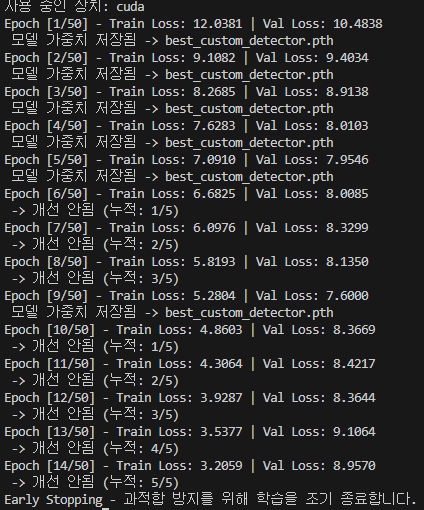

## Train 결과 분석

CUDA 가속 환경에서 Custom Model을 학습하였으며, 최대 학습 횟수는 50 Epoch, Early Stopping의 Patience는 5로 설정하였다.

학습 결과 Train Loss는 1 Epoch의 12.0381에서 14 Epoch의 3.2059까지 지속적으로 감소하였다. 반면 Validation Loss는 9 Epoch에서 7.6000으로 최저값을 기록한 이후 더 이상 개선되지 않고 정체하거나 증가하는 경향을 보였다.

이는 모델이 학습 데이터에 대해서는 지속적으로 성능이 향상되었지만, 9 Epoch 이후 검증 데이터에 대한 일반화 성능은 더 이상 개선되지 않았음을 의미한다.

Validation Loss가 연속 5 Epoch 동안 개선되지 않아 Early Stopping이 적용되었으며, 학습은 14 Epoch에서 종료되었다. 최종적으로 Validation Loss가 가장 낮았던 9 Epoch 시점의 가중치를 `best_custom_detector.pth`로 저장하였다.

초기 학습 단계에서는 Train Loss와 Validation Loss가 함께 감소하며 정상적으로 학습이 진행되었다. 그러나 이후 두 Loss의 차이가 증가하면서 과적합 경향이 나타났다. 향후 Data Augmentation, Weight Decay, Learning Rate 조정 및 데이터 다양성 확대를 적용하면 일반화 성능을 개선할 수 있을 것으로 판단된다.


## 중간 과정 시각화

Custom Model의 내부 탐지 과정을 분석하기 위해 Feature Map과 NMS 적용 전 후보 박스를 시각화하였다.

- Backbone의 마지막 계층인 `block6`에서 Feature Map을 추출하고, 이를 Heatmap으로 변환하여 모델이 중요하게 반응한 영역을 확인하였다.
- Head 출력값을 이용해 NMS 적용 전 후보 박스를 원본 이미지 위에 표시하여 Anchor Box 기반 후보 영역 탐색 과정을 확인하였다.
- 이를 통해 Custom Model이 객체가 존재할 가능성이 높은 영역에 반응하고, 여러 후보 박스를 생성하는 과정을 분석할 수 있었다.

사용 장치: cuda
선택된 이미지: ppe_0545_jpg.rf.9f0b88adeb36543553de081b1f1261e5.jpg


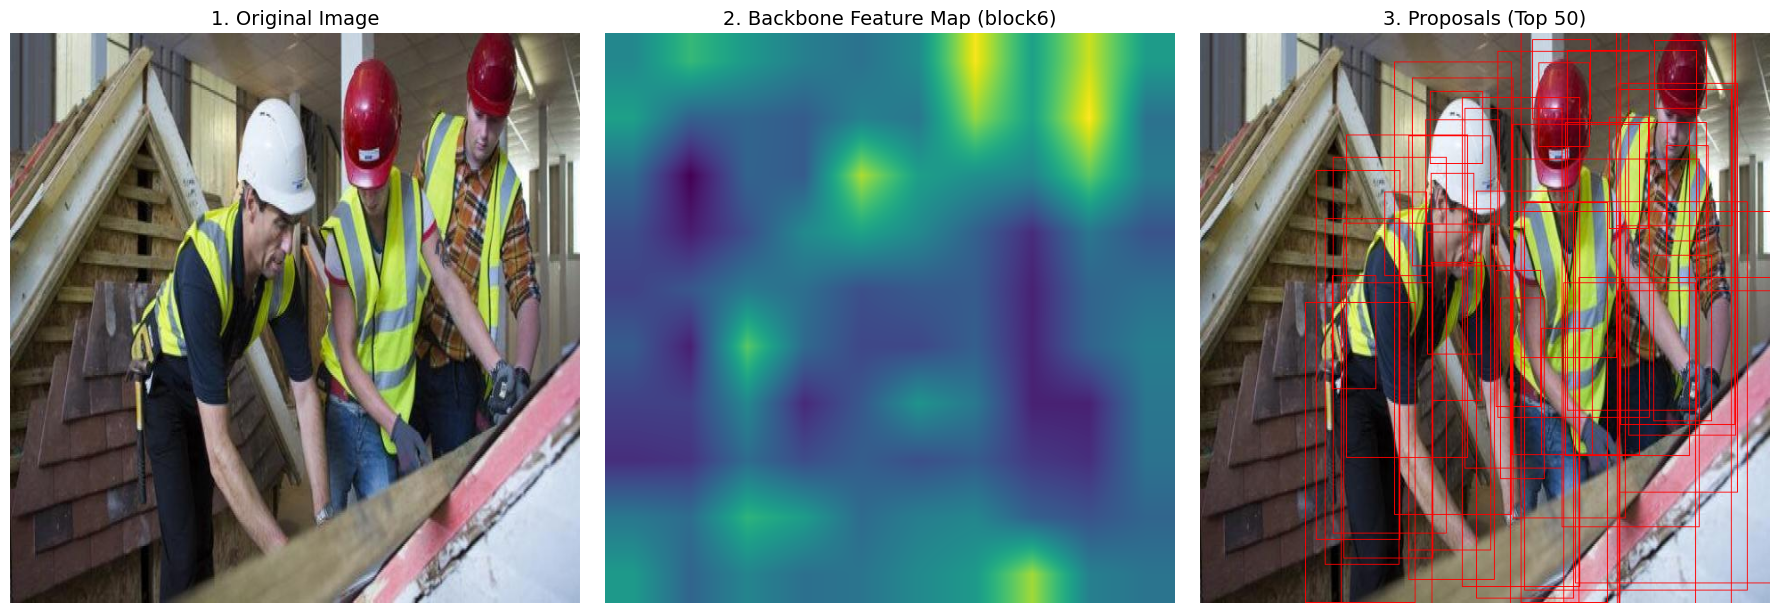

In [ ]:
# 포워드 훅(Hook)으로 추출한 특징 맵을 저장할 전역 딕셔너리
activation = {}

"""특정 레이어의 출력값을 activation 딕셔너리에 저장하는 훅 함수"""
def get_activation(name):
    def hook(model, input, output):
        activation[name] = output.detach()
    return hook

def visualize_internals_with_hook():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"사용 장치: {device}")

    # 1. 모델 불러오기 (기존 Custom 클래스 그대로 사용)
    model = Custom().to(device)

    # 가중치 파일 로드
    try:
        model.load_state_dict(torch.load("/content/drive/MyDrive/기계학습_2조/data/processed/Detection/best_custom_detector.pth", map_location=device))
    except FileNotFoundError:
        print("가중치 파일을 찾을 수 없습니다.")
        return

    model.eval()

    # block6를 통과하는 순간의 데이터가 activation['block6']에 저장
    hook_handle = model.block6.register_forward_hook(get_activation('block6'))

    # 2. 지정된 드라이브 경로에서 랜덤 이미지 선택
    TEST_IMG_DIR = "/content/drive/MyDrive/기계학습_2조/data/processed/Detection/images/test"

    if not os.path.exists(TEST_IMG_DIR):
        print(f"폴더를 찾을 수 없습니다.\n경로: {TEST_IMG_DIR}")
        hook_handle.remove()
        return

    test_images = [f for f in os.listdir(TEST_IMG_DIR) if f.endswith('.jpg')]

    if len(test_images) == 0:
        print(f"해당 폴더에 jpg 이미지가 없습니다.")
        hook_handle.remove()
        return

    # 무작위로 1장 선택
    selected_img_name = random.choice(test_images)
    img_path = os.path.join(TEST_IMG_DIR, selected_img_name)
    print(f"선택된 이미지: {selected_img_name}")

    original_img = Image.open(img_path).convert("RGB")

    transform = transforms.Compose([
        transforms.Resize((640, 640)),
        transforms.ToTensor()
    ])

    img_tensor = transform(original_img).unsqueeze(0).to(device)

    transform = transforms.Compose([
        transforms.Resize((640, 640)),
        transforms.ToTensor()
    ])

    img_tensor = transform(original_img).unsqueeze(0).to(device)

    # 3. 예측 수행
    with torch.no_grad():
        prediction = model(img_tensor)

    # 예측이 끝났으므로 훅 제거
    hook_handle.remove()

    # 4. 특징 맵 및 예측 결과 처리
    out = prediction[0]

    # [과정 2] 특징 맵 추출 (Hook을 통해 저장된 데이터 가져오기)
    # shape: (Batch, 128, 10, 10) -> (128, 10, 10)
    feature_map = activation['block6'][0]

    # 128개의 채널을 평균 내어 1장의 10x10 히트맵으로 압축
    fmap_tensor = feature_map.mean(dim=0).cpu().numpy()

    # [과정 3] 후보 박스(Proposals) 수집
    raw_boxes = []
    for i in range(10):
        for j in range(10):
            for a in range(2):
                conf = out[i, j, a, 4].item()
                # NMS 전이므로 확신도 임계값을 0.05 정도로 낮게 잡아 최대한 많은 후보를 수집
                if conf > 0.05:
                    x_cell, y_cell = out[i, j, a, 0].item(), out[i, j, a, 1].item()
                    w, h = out[i, j, a, 2].item(), out[i, j, a, 3].item()

                    cx = (j + x_cell) * 64
                    cy = (i + y_cell) * 64
                    bw = w * 640
                    bh = h * 640

                    xmin, ymin = cx - bw / 2, cy - bh / 2
                    xmax, ymax = cx + bw / 2, cy + bh / 2

                    raw_boxes.append([xmin, ymin, xmax, ymax, conf])

    # 확신도(Confidence) 기준으로 내림차순 정렬 후 상위 50개만 추출
    raw_boxes = sorted(raw_boxes, key=lambda x: x[4], reverse=True)[:50]

    # 시각화를 위한 이미지 캔버스 준비
    resized_img = original_img.resize((640, 640))
    draw_img = resized_img.copy()
    draw = ImageDraw.Draw(draw_img)

    # 추출된 50개의 후보 박스를 빨간색 얇은 테두리로 그림
    for box in raw_boxes:
        xmin, ymin, xmax, ymax, _ = box
        draw.rectangle([xmin, ymin, xmax, ymax], outline="red", width=1)

    # 5. Matplotlib 화면 분할 및 시각화 (1행 3열)
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # (1) 원본 이미지
    axes[0].imshow(resized_img)
    axes[0].axis('off')
    axes[0].set_title("1. Original Image", fontsize=14)

    # (2) 특징 맵 (10x10 히트맵을 이미지 크기에 맞춰 시각화)
    # 640x640 크기에 맞춰 부드럽게(bilinear) 보간하여 표시
    axes[1].imshow(fmap_tensor, cmap='viridis', interpolation='bilinear')
    axes[1].axis('off')
    axes[1].set_title("2. Backbone Feature Map (block6)", fontsize=14)

    # (3) Proposals (Top 50)
    axes[2].imshow(draw_img)
    axes[2].axis('off')
    axes[2].set_title(f"3. Proposals (Top {len(raw_boxes)})", fontsize=14)

    plt.tight_layout()
    plt.show()

# 함수 실행
if __name__ == "__main__":
    visualize_internals_with_hook()

## test로직

- 하나의 객체에 여러 bounding box가 중복 생성되는 문제를 줄이기 위해 NMS 적용
- IoU를 사용하여 두 박스의 겹침 정도 계산
- confidence score가 높은 박스부터 선택
- 같은 클래스에서 IoU가 0.4 이상인 박스는 중복 예측으로 판단하여 제거
- 최종적으로 객체당 가장 신뢰도 높은 박스만 남김



In [ ]:
# 실전 배치 설계: IoU 계산 및 NMS
"""두 박스가 겹치는 면적 비율(IoU) 계산"""
def calculate_iou(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    intersection = max(0, x2 - x1) * max(0, y2 - y1)
    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])

    union = area1 + area2 - intersection
    return intersection / union if union > 0 else 0

"""실전 배치 설계(중복제거) 구현"""
def non_max_suppression(boxes, iou_threshold=0.4):
    # 1. 확신도가 가장 높은 순서대로 박스들을 줄 세움
    boxes = sorted(boxes, key=lambda x: x[4], reverse=True)
    keep_boxes = []

    while boxes:
        # 2. 확신도 1등 박스를 '대장 박스'로 뽑음
        chosen_box = boxes.pop(0)
        keep_boxes.append(chosen_box)

        # 3. 나머지 박스들 중, 대장 박스와 겹치는 면적이 크고 클래스가 같은 건 전부 삭제
        boxes = [box for box in boxes if box[5] != chosen_box[5] or calculate_iou(chosen_box[:4], box[:4]) < iou_threshold]

    return keep_boxes


## Custom Model 평가 및 NMS 후처리

Custom Model의 원시 예측 결과에는 하나의 객체 주변에 여러 bounding box가 중복으로 생성될 수 있다. 이를 해결하기 위해 IoU 계산 함수와 NMS(Non-Maximum Suppression)를 직접 구현하였다.

NMS는 confidence score가 높은 박스부터 선택한 뒤, 같은 클래스이면서 IoU가 0.4 이상인 박스를 중복 예측으로 판단하여 제거하는 방식으로 동작한다. 이를 통해 최종적으로 객체당 가장 신뢰도 높은 bounding box만 남기도록 하였다.

평가 단계에서는 저장된 최적 가중치를 불러오고, 테스트 데이터셋 전체에 대해 예측을 수행하였다. 예측 결과는 confidence score 0.5 기준으로 필터링하고, NMS를 적용한 뒤 TorchMetrics의 `MeanAveragePrecision` 모듈을 사용하여 mAP@0.5와 Recall을 계산하였다.

이를 통해 Custom Model의 전체 탐지 성능뿐만 아니라 클래스별 탐지 성능까지 정량적으로 확인하였다.


In [ ]:
# 파이프라인 실행
def test1():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"사용 장치: {device}")

    # 1. 학습된 모델 불러오기
    model = Custom().to(device)
    model.load_state_dict(torch.load("/content/drive/MyDrive/기계학습_2조/data/processed/Detection/best_custom_detector.pth", map_location=device))
    model.eval()

    CLASSES = ["helmet", "no-helmet", "no-vest", "person", "vest"]

    # torchmetrics mAP 계산기 초기화 (클래스별 지표 추출 활성화)
    metric = MeanAveragePrecision(box_format='xyxy', iou_type='bbox', class_metrics=True).to(device)

    # 2. 테스트 폴더 및 라벨 폴더 설정
    BASE_DIR = "/content/drive/MyDrive/기계학습_2조/data/processed/Detection"
    TEST_IMG_DIR = f"{BASE_DIR}/images/test"
    TEST_LABEL_DIR = f"{BASE_DIR}/yolo_labels/test"

    test_images = [f for f in os.listdir(TEST_IMG_DIR) if f.endswith('.jpg')]
    if len(test_images) == 0:
        print("테스트 이미지가 없습니다.")
        return

    transform = transforms.Compose([
        transforms.Resize((640, 640)),
        transforms.ToTensor()
    ])

    # 3. 전체 테스트 이미지를 돌며 정답(GT)과 예측(Pred)을 수집하여 metric에 누적
    for img_name in test_images:
        img_path = os.path.join(TEST_IMG_DIR, img_name)
        label_path = os.path.join(TEST_LABEL_DIR, img_name.replace(".jpg", ".txt"))

        # [정답(GT) 수집 로직]
        gt_boxes_list = []
        gt_labels_list = []

        if os.path.exists(label_path):
            with open(label_path, "r") as f:
                for line in f.readlines():
                    class_label, x, y, w, h = map(float, line.strip().split())

                    cx, cy = x * 640, y * 640
                    bw, bh = w * 640, h * 640
                    xmin, ymin = cx - bw / 2, cy - bh / 2
                    xmax, ymax = cx + bw / 2, cy + bh / 2

                    gt_boxes_list.append([xmin, ymin, xmax, ymax])
                    gt_labels_list.append(int(class_label))

        # torchmetrics가 요구하는 정답 딕셔너리 포맷
        targets = [{
            "boxes": torch.tensor(gt_boxes_list, dtype=torch.float32).to(device) if gt_boxes_list else torch.empty((0, 4), dtype=torch.float32).to(device),
            "labels": torch.tensor(gt_labels_list, dtype=torch.int64).to(device) if gt_labels_list else torch.empty((0,), dtype=torch.int64).to(device),
        }]

        # [예측(Pred) 수집 로직]
        original_img = Image.open(img_path).convert("RGB")
        img_tensor = transform(original_img).unsqueeze(0).to(device)

        with torch.no_grad():
            prediction = model(img_tensor)

        out = prediction[0]
        raw_boxes = []

        for i in range(10):
            for j in range(10):
                for a in range(2):
                    conf = out[i, j, a, 4].item()
                    if conf > 0.5:
                        x_cell, y_cell = out[i, j, a, 0].item(), out[i, j, a, 1].item()
                        w, h = out[i, j, a, 2].item(), out[i, j, a, 3].item()

                        cx = (j + x_cell) * 64
                        cy = (i + y_cell) * 64
                        bw = w * 640
                        bh = h * 640

                        xmin, ymin = cx - bw / 2, cy - bh / 2
                        xmax, ymax = cx + bw / 2, cy + bh / 2

                        class_id = torch.argmax(out[i, j, a, 5:]).item()
                        raw_boxes.append([xmin, ymin, xmax, ymax, conf, class_id])

        # NMS 통과 (기존에 선언해둔 non_max_suppression 함수 사용)
        final_boxes = non_max_suppression(raw_boxes, iou_threshold=0.4)

        pred_boxes_list = []
        pred_scores_list = []
        pred_labels_list = []

        for pred in final_boxes:
            pred_boxes_list.append([pred[0], pred[1], pred[2], pred[3]])
            pred_scores_list.append(pred[4])
            pred_labels_list.append(pred[5])

        # torchmetrics가 요구하는 예측 딕셔너리 포맷
        preds = [{
            "boxes": torch.tensor(pred_boxes_list, dtype=torch.float32).to(device) if pred_boxes_list else torch.empty((0, 4), dtype=torch.float32).to(device),
            "scores": torch.tensor(pred_scores_list, dtype=torch.float32).to(device) if pred_scores_list else torch.empty((0,), dtype=torch.float32).to(device),
            "labels": torch.tensor(pred_labels_list, dtype=torch.int64).to(device) if pred_labels_list else torch.empty((0,), dtype=torch.int64).to(device),
        }]

        # 이미지를 1장씩 넘길 때마다 metric에 데이터를 누적
        metric.update(preds, targets)

    # 4. 모든 테스트 이미지의 누적이 끝나면 한 번에 최종 AP 및 Recall 계산
    results = metric.compute()

    # mAP@0.5와 최대 100개 탐지 기준의 Average Recall(mAR) 추출
    mAP_50 = results['map_50'].item()
    Recall = results['mar_100'].item()

    print("==================================================")
    print(f"종합 mAP (IoU 0.50)      : {mAP_50:.4f}")
    print(f"종합 재현율 (Recall)    : {Recall:.4f}")
    print("--------------------------------------------------")
    print("클래스별 상세 mAP 및 재현율")

    # 클래스별 세부 지표 파싱 및 출력
    if 'map_per_class' in results and 'classes' in results:
        map_per_class = results['map_per_class'].tolist()
        mar_per_class = results['mar_100_per_class'].tolist()
        classes_present = results['classes'].tolist() # 이번 평가에서 1번이라도 등장한 클래스 ID들

        for c_idx in range(len(CLASSES)):
            class_name = CLASSES[c_idx].title()
            if c_idx in classes_present:
                list_idx = classes_present.index(c_idx)
                c_map = map_per_class[list_idx]
                c_mar = mar_per_class[list_idx]
                print(f" - {class_name:<9} : mAP = {c_map:.4f} / Recall = {c_mar:.4f}")
            else:
                print(f" - {class_name:<9} : 데이터 없음 (또는 모델 예측 불가)")

if __name__ == "__main__":
    test1()

사용 장치: cuda
종합 mAP (IoU 0.50)      : 0.1111
종합 재현율 (Recall)    : 0.0645
--------------------------------------------------
클래스별 상세 mAP 및 재현율
 - Helmet    : mAP = 0.0500 / Recall = 0.1297
 - No-Helmet : mAP = 0.0000 / Recall = 0.0000
 - No-Vest   : mAP = 0.0191 / Recall = 0.0328
 - Person    : mAP = 0.0414 / Recall = 0.1079
 - Vest      : mAP = 0.0229 / Recall = 0.0519


## Custom Model 추론 결과 시각화

정량적 평가 결과를 보완하기 위해, 모델이 실제 테스트 이미지에서 안전 요소를 어떻게 탐지하는지 시각적으로 확인하였다. 특정 이미지에만 편향되지 않도록 전체 테스트 이미지 중 5장을 무작위로 추출하여 추론을 수행하였다.



사용 장치: cuda
전체 90장 중 무작위로 5장을 선정하여 코랩 화면에 시각화합니다...



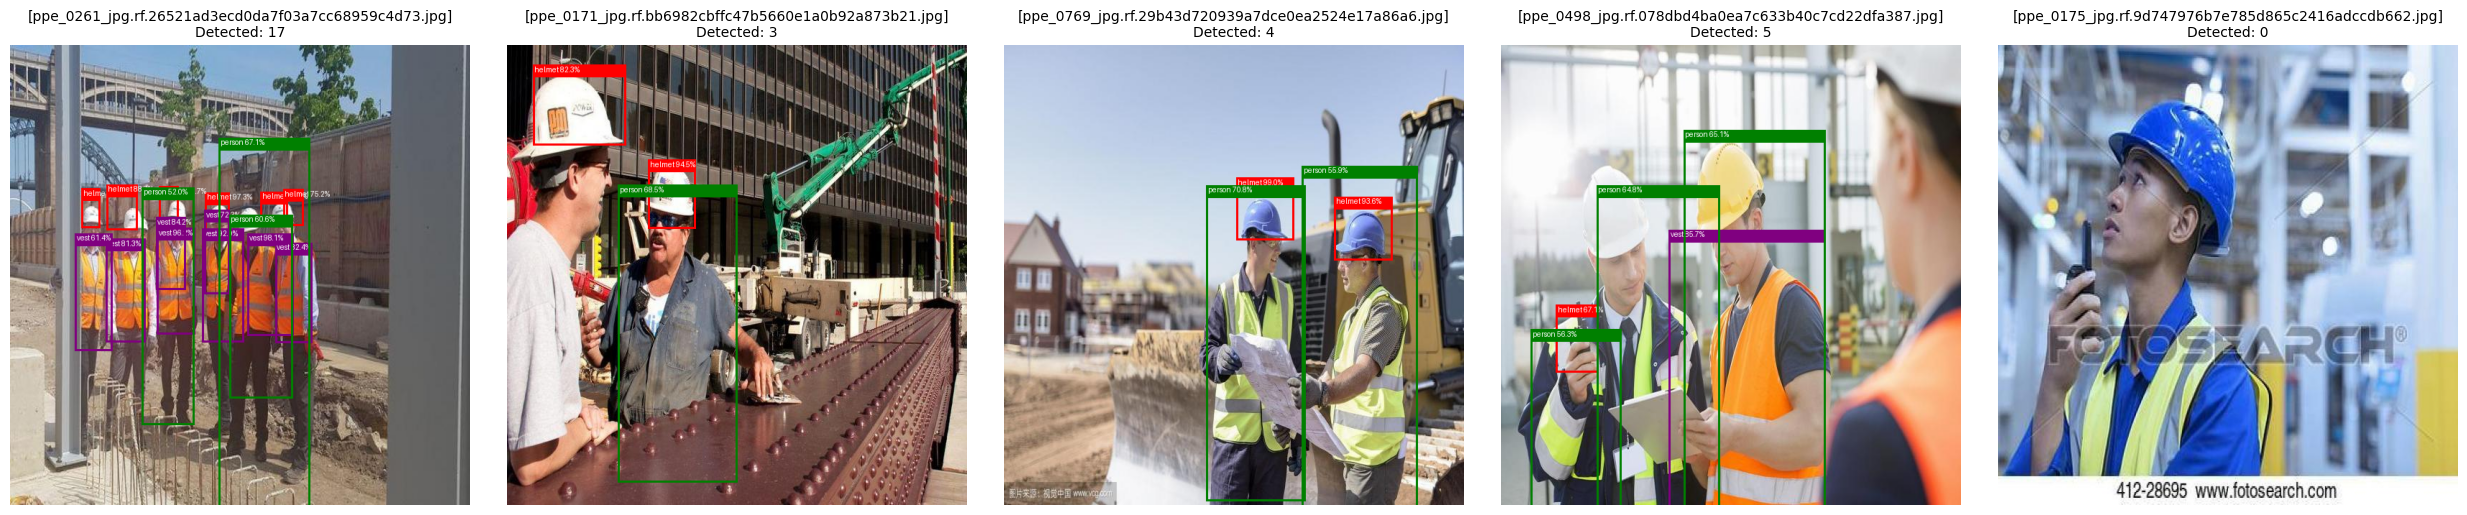

In [ ]:
# 파이프라인 실행 (무작위 5장 추출하여 시각화)
def test2():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"사용 장치: {device}")

    # 1. 학습된 모델 불러오기
    BASE_DIR = "/content/drive/MyDrive/기계학습_2조/data/processed/Detection"
    model = Custom().to(device)
    model.load_state_dict(torch.load("/content/drive/MyDrive/기계학습_2조/data/processed/Detection/best_custom_detector.pth", map_location=device))
    model.eval() # 평가 모드

    CLASSES = ["helmet", "no-helmet", "no-vest", "person", "vest"]
    COLORS = ["red", "orange", "blue", "green", "purple"]

    # 2. 테스트 폴더
    TEST_IMG_DIR = f"{BASE_DIR}/images/test"

    # 폴더 안의 jpg 파일 목록 가져오기
    test_images = [f for f in os.listdir(TEST_IMG_DIR) if f.endswith('.jpg')]

    if len(test_images) == 0:
        print(f"경고: {TEST_IMG_DIR} 폴더에 테스트할 jpg 이미지가 없습니다.")
        return

    # 무작위로 5장 선택
    num_samples = min(5, len(test_images))
    random_selected_images = random.sample(test_images, num_samples)

    print(f"전체 {len(test_images)}장 중 무작위로 {num_samples}장을 선정하여 코랩 화면에 시각화합니다...\n")

    transform = transforms.Compose([
        transforms.Resize((640, 640)),
        transforms.ToTensor()
    ])

    # 코랩 출력을 위해 matplotlib figure 준비
    fig, axes = plt.subplots(1, num_samples, figsize=(5 * num_samples, 5))

    # 1장만 뽑힐 경우 axes가 배열이 아닐 수 있으므로 리스트로 감싸줌
    if num_samples == 1:
        axes = [axes]

    # 3. 선택된 5장의 사진만 반복 테스트
    for idx, img_name in enumerate(random_selected_images):
        img_path = os.path.join(TEST_IMG_DIR, img_name)
        original_img = Image.open(img_path).convert("RGB")

        img_tensor = transform(original_img).unsqueeze(0).to(device)

        with torch.no_grad():
            prediction = model(img_tensor)

        out = prediction[0]
        raw_boxes = []

        # 10x10 격자에서 앵커 2개를 모두 확인
        for i in range(10):
            for j in range(10):
                for a in range(2):
                    conf = out[i, j, a, 4].item()
                    if conf > 0.5:
                        x_cell, y_cell = out[i, j, a, 0].item(), out[i, j, a, 1].item()
                        w, h = out[i, j, a, 2].item(), out[i, j, a, 3].item()

                        cx = (j + x_cell) * 64
                        cy = (i + y_cell) * 64
                        bw = w * 640
                        bh = h * 640

                        xmin, ymin = cx - bw / 2, cy - bh / 2
                        xmax, ymax = cx + bw / 2, cy + bh / 2

                        class_id = torch.argmax(out[i, j, a, 5:]).item()
                        raw_boxes.append([xmin, ymin, xmax, ymax, conf, class_id])

        # 4. NMS 통과
        final_boxes = non_max_suppression(raw_boxes, iou_threshold=0.4)

        # 5. 시각화 및 개별 저장
        draw_img = original_img.resize((640, 640))
        draw = ImageDraw.Draw(draw_img)

        for box in final_boxes:
            xmin, ymin, xmax, ymax, conf, class_id = box
            label = f"{CLASSES[class_id]} {conf*100:.1f}%"
            color = COLORS[class_id]

            draw.rectangle([xmin, ymin, xmax, ymax], outline=color, width=3)
            draw.rectangle([xmin, ymin-15, xmax, ymin], fill=color)
            draw.text((xmin+2, ymin-15), label, fill="white")

        # 저장 이름 지정 및 저장
        save_name = img_name.replace(".jpg", "_random_result.jpg")

        axes[idx].imshow(draw_img)
        axes[idx].axis('off') # 불필요한 축의 눈금은 숨김
        axes[idx].set_title(f"[{img_name}]\nDetected: {len(final_boxes)}", fontsize=10)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    test2()